In [66]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Function
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import *

In [67]:
from qiskit import QuantumCircuit as QiskitCircuit, transpile
from qiskit.circuit import Parameter

class QuantumCircuit:
    """Simple interface for running parameterized quantum circuits."""

    def __init__(self, n_qubits, backend, shots):
        self.backend = backend
        self.shots = shots

        self.theta = Parameter('theta')
        self._circuit = QiskitCircuit(n_qubits)

        all_qubits = list(range(n_qubits))
        self._circuit.h(all_qubits)
        self._circuit.barrier()
        self._circuit.ry(self.theta, all_qubits)
        self._circuit.measure_all()

    def run(self, thetas):
        results = []

        for theta in thetas:
            # Bind parameter value
            bound_circuit = self._circuit.assign_parameters({self.theta: theta}, inplace=False)

            # Transpile and run
            compiled = transpile(bound_circuit, self.backend)
            job = self.backend.run(compiled, shots=self.shots)
            result = job.result().get_counts()

            # Calculate expectation value
            counts = np.array(list(result.values()))
            states = np.array([int(state, 2) for state in result.keys()])
            probabilities = counts / self.shots
            expectation = np.sum(states * probabilities)

            results.append(expectation)

        return np.array(results)


In [68]:
backend = Aer.get_backend("aer_simulator_statevector")
qc = QuantumCircuit(n_qubits=1, backend=backend, shots=1000)

expectations = qc.run([0, np.pi/2, np.pi])
print(expectations)

[0.517 1.    0.492]


In [69]:
class HybridFunction(Function):
    @staticmethod
    def forward(ctx, input, quantum_circuit, shift):
        ctx.shift = shift
        ctx.quantum_circuit = quantum_circuit

        # Convert input to numpy for batch processing
        input_np = input.detach().cpu().numpy()
        results = []

        # Run quantum circuit for all samples in the batch
        for i in range(input_np.shape[0]):
            expectation_z = quantum_circuit.run(input_np[i])
            results.append([expectation_z])  # keep 2D shape

        result = torch.tensor(results, dtype=input.dtype, device=input.device)
        ctx.save_for_backward(input, result)
        return result

    @staticmethod
    def backward(ctx, grad_output):
        input, expectation_z = ctx.saved_tensors
        input_np = input.detach().cpu().numpy()
        shift = ctx.shift

        # Prepare shifts
        shift_right = input_np + shift
        shift_left = input_np - shift

        gradients = []
        for i in range(input_np.shape[0]):
            grad = ctx.quantum_circuit.run(shift_right[i]) - ctx.quantum_circuit.run(shift_left[i])
            gradients.append([grad])  # keep 2D
        gradients = torch.tensor(gradients, dtype=input.dtype, device=input.device)

        return gradients * grad_output, None, None


class Hybrid(nn.Module):
    def __init__(self, backend, shots, shift):
        super(Hybrid, self).__init__()
        self.quantum_circuit = QuantumCircuit(1, backend, shots)
        self.shift = shift

    def forward(self, input):
        # Directly apply batch hybrid function
        return HybridFunction.apply(input, self.quantum_circuit, self.shift)


In [70]:

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# --- Parameters ---
batch_size = 32
train_proportion = 0.8  # 80% training, 20% testing

# --- Transform ---
transform = transforms.Compose([transforms.ToTensor()])

# --- Load full MNIST dataset ---
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# --- Filter only digits 1 and 7 ---
indices_1 = np.where(mnist_dataset.targets == 1)[0]
indices_7 = np.where(mnist_dataset.targets == 7)[0]

# --- Split indices according to proportion ---
train_idx_1 = indices_1[:int(len(indices_1) * train_proportion)]
test_idx_1  = indices_1[int(len(indices_1) * train_proportion):]

train_idx_7 = indices_7[:int(len(indices_7) * train_proportion)]
test_idx_7  = indices_7[int(len(indices_7) * train_proportion):]

train_idx = np.concatenate([train_idx_1, train_idx_7])
test_idx  = np.concatenate([test_idx_1, test_idx_7])

# --- Create Subsets ---
train_dataset = Subset(mnist_dataset, train_idx)
test_dataset  = Subset(mnist_dataset, test_idx)

# --- Remap labels: 1 -> 0, 7 -> 1 ---
def remap_labels(subset):
    for i in range(len(subset)):
        img, label = subset[i]
        subset.dataset.targets[subset.indices[i]] = 0 if label == 1 else 1

remap_labels(train_dataset)
remap_labels(test_dataset)

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
print(f"Training set size: {len(train_dataset)}")
print(f"Testing set size: {len(test_dataset)}")

Training set size: 10405
Testing set size: 2602


In [71]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.dropout = nn.Dropout2d()
        self.fc1 = nn.Linear(256, 64)
        
        # Output 2 logits for the 2 classes
        self.fc2 = nn.Linear(64, 2)
        
        # Hybrid layer can remain, but output should match 2 classes
        self.hybrid = Hybrid(Aer.get_backend("aer_simulator_statevector"), 100, np.pi / 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        
        # Classical output logits
        x = self.fc2(x)
        
        # Optional: apply hybrid per logit if needed
        # Example: x = torch.stack([self.hybrid(sample) for sample in x])
        
        return x  # Return raw logits [batch_size, 2]




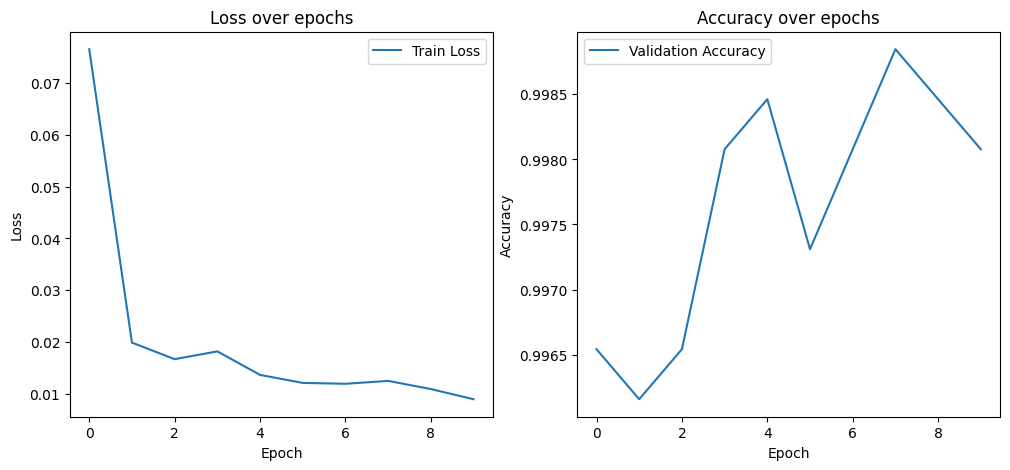

Epoch 10/10 | Train Loss: 0.0089| Val Loss: 0.0054, Val Acc: 0.9981


In [72]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

model = Net()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()


epochs = 10
train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []

for epoch in range(epochs):
    # --- Training ---
    model.train()
    total_loss = []
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()

        total_loss.append(loss.item())
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    train_loss = sum(total_loss) / len(total_loss)
    train_acc = correct / total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            val_loss += loss_func(output, target).item()
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    val_loss /= len(test_loader)
    val_acc = correct / total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    # --- Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_loss_list, label='Train Loss')
    # plt.plot(val_loss_list, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over epochs')
    plt.legend()

    plt.subplot(1,2,2)
    # plt.plot(train_acc_list, label='Train Accuracy')
    plt.plot(val_acc_list, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over epochs')
    plt.legend()

    plt.show()

    print(f'Epoch {epoch+1}/{epochs} | '
          f'Train Loss: {train_loss:.4f}| '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

In [75]:
model.eval()
total_loss = []

with torch.no_grad():
    correct = 0
    total = 0
    for data, target in test_loader:
        output = model(data)
        
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)  # accumulate total number of samples
        
        loss = loss_func(output, target)
        total_loss.append(loss.item())
        
    print('Performance on test data:\n\tLoss: {:.4f}\n\tAccuracy: {:.1f}%'.format(
        sum(total_loss) / len(total_loss),
        correct / total * 100  # divide by total samples, not batches
    ))


Performance on test data:
	Loss: 0.0054
	Accuracy: 99.8%


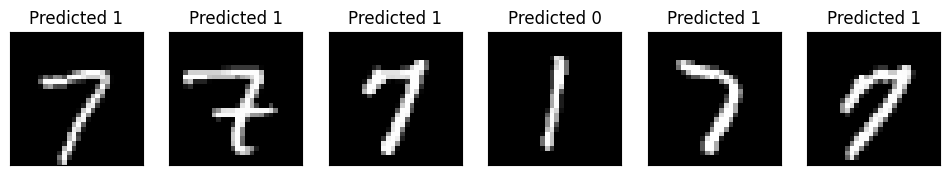

In [76]:
import matplotlib.pyplot as plt

n_samples_show = 6
count = 0
fig, axes = plt.subplots(1, n_samples_show, figsize=(12, 3))

model.eval()
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        for i in range(data.size(0)):
            if count == n_samples_show:
                break

            output = model(data[i].unsqueeze(0))  # keep batch dimension for model
            pred = output.argmax(dim=1, keepdim=True)

            axes[count].imshow(data[i].numpy().squeeze(), cmap='gray')
            axes[count].set_xticks([])
            axes[count].set_yticks([])
            axes[count].set_title(f'Predicted {pred.item()}')

            count += 1
        if count == n_samples_show:
            break

plt.show()
